# Робота з даними про сердцеві захворювання


Ініціалізуємо необхідні бібліотеки.

In [1]:
import os
import zipfile
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates

Завантажимо zip-архів з датасетом.

In [2]:
def download_file():
    os.makedirs("data", exist_ok=True)

    url = "https://archive.ics.uci.edu/static/public/45/heart+disease.zip"
    zip_path = "data/heart+disease.zip"
    extract_path = "data/heart_disease"
    output_csv = "data/heart_disease.csv"


    if not os.path.isdir(extract_path):
        os.makedirs(extract_path, exist_ok=True)
        if not os.path.isfile(zip_path):
            response = requests.get(url)
            with open(zip_path, "wb") as file:
                file.write(response.content)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(extract_path)

    columns = [
        "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
        "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"
    ]

    files_with_territory = {
        "processed.cleveland.data": "Cleveland",
        "processed.hungarian.data": "Hungary",
        "processed.switzerland.data": "Switzerland",
        "processed.va.data": "VA Long Beach"
    }

    dfs = []

    for filename, territory in files_with_territory.items():
        file_path = os.path.join(extract_path, filename)

        df_part = pd.read_csv(file_path, header=None, names=columns, na_values="?")

        df_part["territory"] = territory
        dfs.append(df_part)

    df = pd.concat(dfs, ignore_index=True)

    df.to_csv(output_csv, index=False)

download_file()

Створимо DataFrame з файлу та здійснимо Data Cleaning.

In [3]:
def csv_to_df():
    df = pd.read_csv("data/heart_disease.csv")

    df.replace("?", np.nan, inplace=True)
    df.dropna(inplace=True)

    df.drop(columns=['fbs','restecg','exang','slope', 'cp'], inplace=True)

    numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'thal', 'num']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df['sex'] = df['sex'].map({0: 'Female', 1: 'Male'})

    df['disease'] = df['num'].map({
        0: 'No disease',
        1: 'Disease',
        2: 'Disease',
        3: 'Disease',
        4: 'Disease'
    })

    df.drop(columns=['num'], inplace=True)

    return df

df_med = csv_to_df()

Побудувати графіки залежності одного integer/real атрибута від іншого (lineplot, scatter etc).

Для візуалізації залежності максимальної ЧСС від віку я обрав scatterplot, оскільки цей тип графіка найкраще підходить для відображення зв’язку між двома кількісними змінними. Він дозволяє показати кожне окреме спостереження у вигляді точки на площині, що дає змогу не лише оцінити загальну тенденцію, а й побачити щільність розподілу даних, варіативність показників та можливі викиди. З медичної точки зору такий графік дає можливість простежити, як із віком змінюється максимальна частота серцевих скорочень, яка є важливим показником функціональної реакції серця на навантаження.

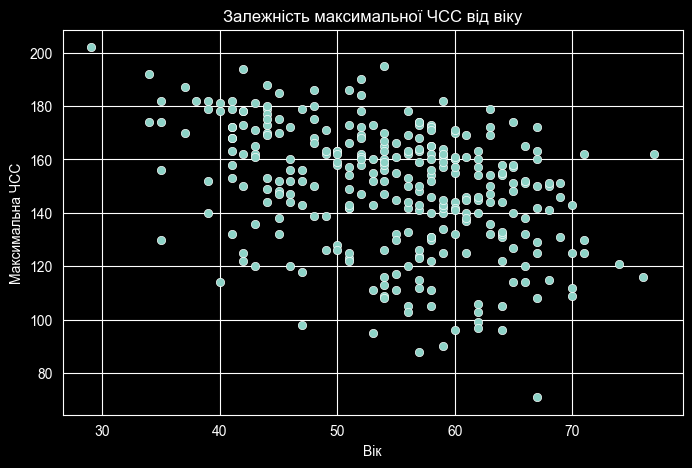

In [4]:
def scatterplot():
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df_med, x='age', y='thalach')
    plt.title('Залежність максимальної ЧСС від віку')
    plt.xlabel('Вік')
    plt.ylabel('Максимальна ЧСС')
    plt.show()

scatterplot()

Для візуалізації середнього рівня холестерину залежно від віку я обрав lineplot, оскільки цей тип графіка добре підходить для відображення зміни усередненого числового показника вздовж кількісної змінної у цьому випадку середнього значення chol для кожного віку age. Лінійний графік дозволяє простежити загальну тенденцію та коливання показника між віковими групами, що є зручним для аналізу. З медичної точки зору такий підхід допомагає оцінити, як із віком змінюється середній рівень холестерину, який є одним із важливих факторів серцево-судинного ризику.

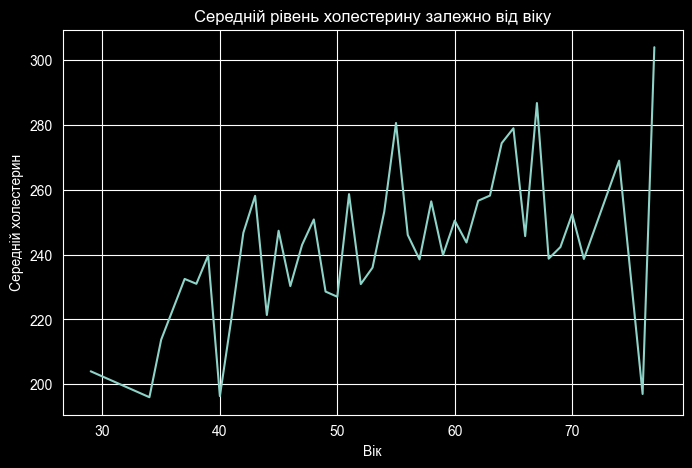

In [5]:
def lineplot():
    mean_chol_by_age = df_med.groupby('age')['chol'].mean().reset_index()

    plt.figure(figsize=(8, 5))
    sns.lineplot(data=mean_chol_by_age, x='age', y='chol')
    plt.title('Середній рівень холестерину залежно від віку')
    plt.xlabel('Вік')
    plt.ylabel('Середній холестерин')
    plt.show()

lineplot()

Побудувати гістограму по одному з атрибутів, що буде показувати на кількість елементів, що знаходяться у 5 діапазонах, які ви задасте.

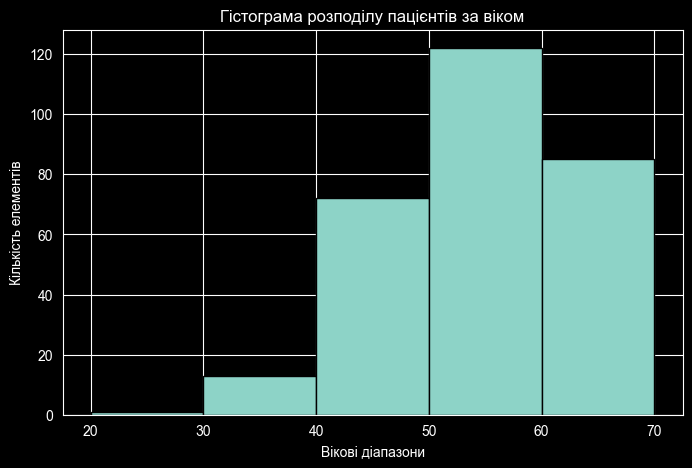

In [6]:
def hist_by_bins():
    bins = list(map(int, input("Введіть 6 значень діапазонів (у форматі: 20 30 40 50 60 70): ").split()))

    plt.figure(figsize=(8, 5))
    plt.hist(df_med['age'].dropna(), bins=bins, edgecolor='black')
    plt.title('Гістограма розподілу пацієнтів за віком')
    plt.xlabel('Вікові діапазони')
    plt.ylabel('Кількість елементів')
    plt.show()

hist_by_bins()

Збудувати графіки, використовуючи приклади, наведені у https://medium.com/data-science/the-art-of-effective-visualization-of-multi-dimensional-data-6c7202990c57

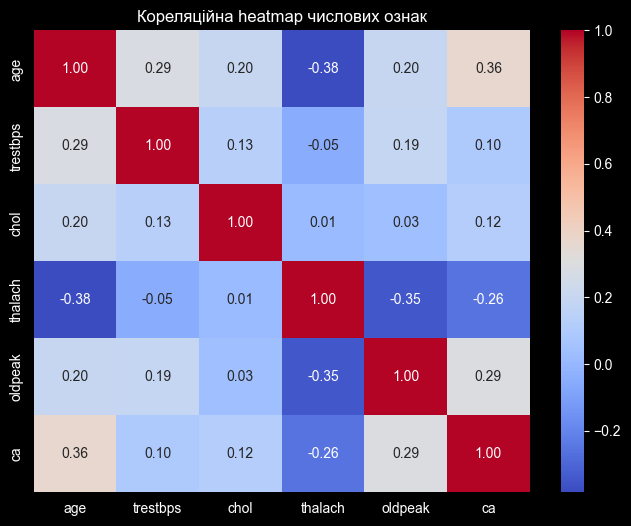

In [7]:
def heatmap():
    num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
    corr = df_med[num_cols].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Кореляційна heatmap числових ознак')
    plt.show()

heatmap()

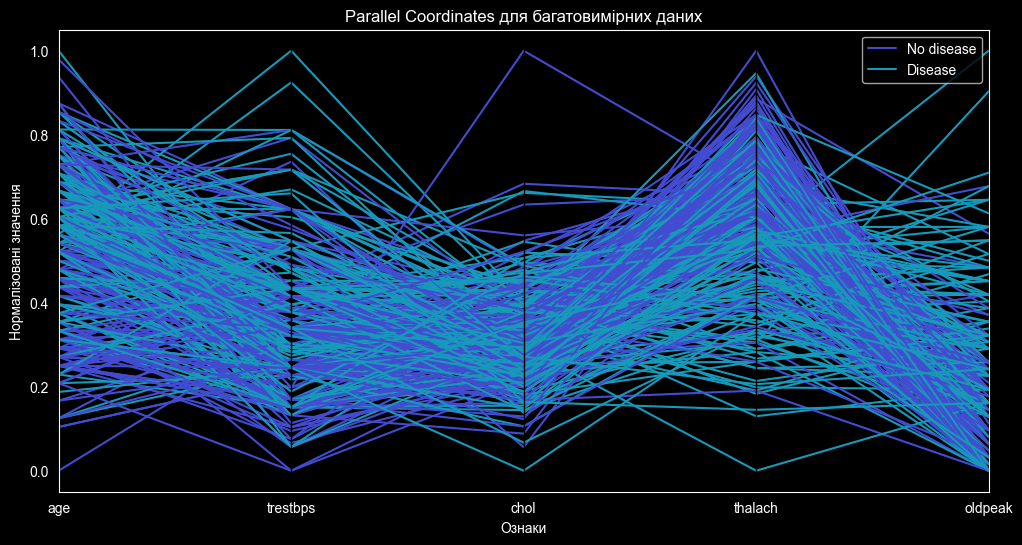

In [8]:
def normalization(df):
    cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
    normalized_df = df.copy()

    for col in cols:
        normalized_df[col] = pd.to_numeric(normalized_df[col], errors='coerce')
        normalized_df[col] = (
            (normalized_df[col] - normalized_df[col].min()) /
            (normalized_df[col].max() - normalized_df[col].min())
        )

    return normalized_df

def plot_with_parallel_coordinates():
    df_pc = df_med[['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'disease']].copy()
    df_pc = normalization(df_pc)

    plt.figure(figsize=(12, 6))
    parallel_coordinates(df_pc, 'disease')
    plt.title('Parallel Coordinates для багатовимірних даних')
    plt.xlabel('Ознаки')
    plt.ylabel('Нормалізовані значення')
    plt.show()

plot_with_parallel_coordinates()

Побудувати інші графіки, що покажуть корисну інформацію про датасет. Загальна кількість графіків має становити 5-8.

Для візуалізації розподілу максимальної ЧСС залежно від наявності хвороби я обрав boxplot, оскільки цей тип графіка ефективно відображає розподіл числової змінної thalach у межах категоріальної ознаки disease. Він дозволяє порівняти медіану, міжквартильний розмах, загальний розкид значень та можливі викиди в обох групах пацієнтів. З медичної точки зору такий графік є корисним для оцінки того, чи відрізняється функціональна реакція серця на навантаження у пацієнтів із серцевим захворюванням і без нього.

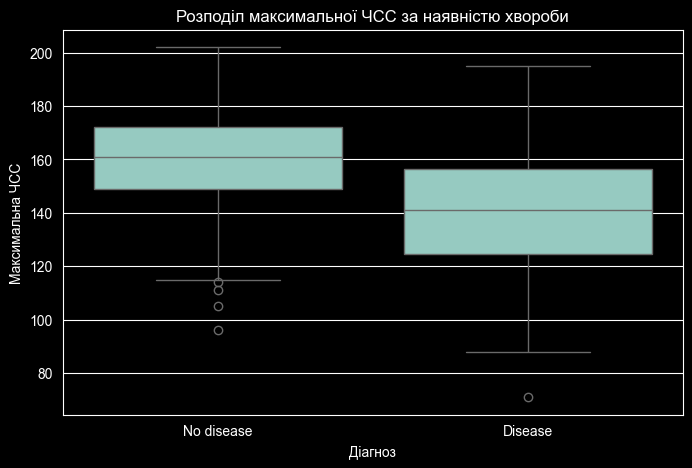

In [9]:
def boxplot():
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_med, x='disease', y='thalach')
    plt.title('Розподіл максимальної ЧСС за наявністю хвороби')
    plt.xlabel('Діагноз')
    plt.ylabel('Максимальна ЧСС')
    plt.show()

boxplot()

Для візуалізації середнього значення oldpeak залежно від діагнозу я обрав barplot, оскільки цей тип графіка добре підходить для порівняння усередненого числового показника між категоріальними групами, у цьому випадку між пацієнтами з наявністю та відсутністю серцевого захворювання. Він дозволяє наочно побачити різницю між середніми значеннями показника, а також оцінити варіативність за допомогою довірчих інтервалів. З медичної точки зору такий графік є корисним, оскільки oldpeak характеризує зміну сегмента ST при навантаженні, а його вищі значення можуть свідчити про більш виражені порушення функціонального стану серця.

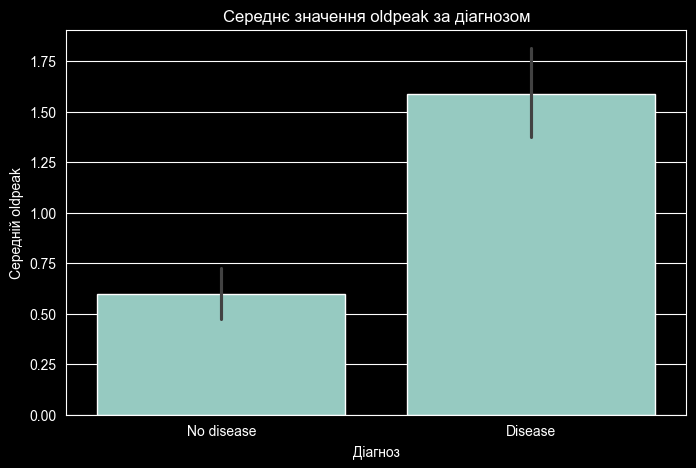

In [10]:
def barplot():
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_med, x='disease', y='oldpeak')
    plt.title('Середнє значення oldpeak за діагнозом')
    plt.xlabel('Діагноз')
    plt.ylabel('Середній oldpeak')
    plt.show()

barplot()